# Clase 3: Función Inicial de Masa (IMF) y Dinámica inicial de un Cúmulo Estelar


## Objetivos
1. La Función Inicial de Masa (IMF) y su origen físico.
2. Límites Fundamentales de la Masa Estelar.
3. Eficiencia y Tasa de Formación Estelar (Kennicutt-Schmidt).
4. Retroalimentación (Feedback) y Mortalidad Infantil


## 1. La Función Inicial de Masa  (IMF) y su Origen Físico

La Función de Masa Inicial, $\xi(m)$, cuantifica la distribución de masas con la que nace una población estelar, definida de modo que $dN = \xi(m) dm$ es el número de estrellas con masa entre $m$ y $m+dm$.

### 1.1 El Pico de la IMF y la Fragmentación de Jeans
Históricamente, los modelos iniciales (como el de Salpeter) predecían una ley de potencias única, la cual diverge si se extrapola a masas infinitamente pequeñas, violando la conservación de masa. Las observaciones modernas demuestran un "quiebre" o pico (*turn-over*) en la IMF alrededor de $0.3 - 0.5 M_\odot$.

Físicamente, este pico no es una anomalía estadística, sino la huella dactilar de la termodinámica del gas en las nubes moleculares gigantes (GMCs). El gas molecular se acopla con el polvo, enfriándose eficientemente hasta los $\sim 10 \text{ K}$. A las densidades típicas de un núcleo pre-estelar ($n_{H_2} \sim 10^4 - 10^5 \text{ cm}^{-3}$), la Masa Crítica de Jeans Termal ($M_J \propto T^{3/2} \rho^{-1/2}$) arroja valores de $\sim 0.5 M_\odot$. Es decir, las estrellas de baja masa dominan el universo porque reflejan el tamaño de fragmentación más probable de la nube debido a las leyes fundamentales del enfriamiento del gas.

### 1.2 La Cola de Masas Altas: Dos Paradigmas
La aparición de estrellas muy masivas (e.g., $30 M_\odot$) exige mecanismos adicionales, ya que la masa de Jeans estándar no las explica. Discutimos dos enfoques principales:
1. **Acreción Competitiva:** Las estrellas masivas no provienen de un núcleo pre-estelar gigante aislado. Nacen como semillas pequeñas en el centro de potencial del cúmulo y, gracias a su posición privilegiada, canalizan el gas del medio a través de acreción de Bondi-Hoyle ($\dot{M} \propto M^2 \rho / v^3$), "robando" material a las estrellas periféricas.
2. **Colapso de Núcleos Turbulentos:** La turbulencia supersónica crea compresiones extremas. Los picos de densidad formados por choques turbulentos generan núcleos masivos sostenidos por presión no térmica (turbulenta) que colapsan monolíticamente.

### 1.3 Representaciones Analíticas de la IMF (más usados)
*   **Salpeter (1955):** $\xi(m) \propto m^{-2.35}$ (Válida para $M > 1 M_\odot$).
*   **Kroupa (2001):** Ley de potencias multipartita:
    *   $\alpha = 0.3$ para $0.01 \le m/M_\odot < 0.08$
    *   $\alpha = 1.3$ para $0.08 \le m/M_\odot < 0.50$
    *   $\alpha = 2.3$ para $m/M_\odot \ge 0.50$
*   **Chabrier (2003):** Lognormal para $m \le 1 M_\odot$ y ley de potencias para $m > 1 M_\odot$.




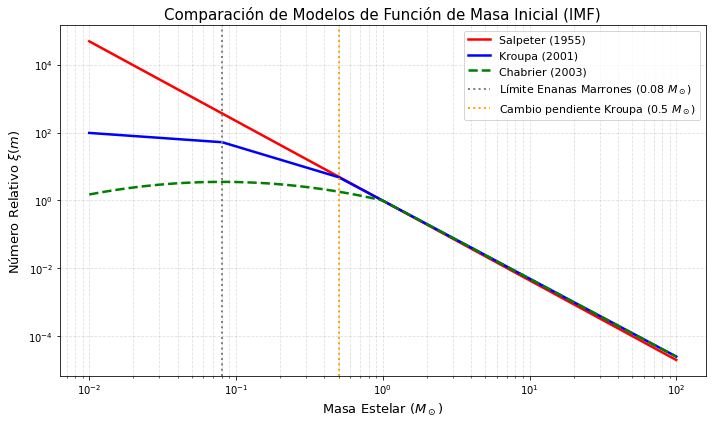

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de masas (de 0.01 a 100 M_sol)
m = np.logspace(-2, 2, 500)

# 1. Salpeter (1955)
salpeter = m**(-2.35)

# 2. Kroupa (2001)
kroupa = np.zeros_like(m)
kroupa[m < 0.08] = m[m < 0.08]**(-0.3)
kroupa[(m >= 0.08) & (m < 0.5)] = (0.08**1.0) * m[(m >= 0.08) & (m < 0.5)]**(-1.3)
kroupa[m >= 0.5] = (0.08**1.0) * (0.5**1.0) * m[m >= 0.5]**(-2.3)

# 3. Chabrier (2003)
chabrier = np.zeros_like(m)
chabrier[m < 1] = 0.158 * np.exp(- (np.log10(m[m < 1]) - np.log10(0.08))**2 / (2 * 0.69**2))
chabrier[m >= 1] = 0.044 * m[m >= 1]**(-2.3)

# Normalización visual en m=1 para facilitar la comparación
idx = np.argmin(np.abs(m - 1))
salpeter /= salpeter[idx]
kroupa /= kroupa[idx]
chabrier /= chabrier[idx]

# Creación de la gráfica estática
plt.figure(figsize=(10, 6))
plt.plot(m, salpeter, 'r-', lw=2.5, label='Salpeter (1955)')
plt.plot(m, kroupa, 'b-', lw=2.5, label='Kroupa (2001)')
plt.plot(m, chabrier, 'g--', lw=2.5, label='Chabrier (2003)')

# Líneas de referencia teóricas
plt.axvline(0.08, color='gray', linestyle=':', lw=2, label='Límite Enanas Marrones (0.08 $M_\odot$)')
plt.axvline(0.5, color='orange', linestyle=':', lw=2, label='Cambio pendiente Kroupa (0.5 $M_\odot$)')

# Detalles estéticos
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Masa Estelar ($M_\odot$)', fontsize=13)
plt.ylabel(r'Número Relativo $\xi(m)$', fontsize=13)
plt.title('Comparación de Modelos de Función de Masa Inicial (IMF)', fontsize=15)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Límites Fundamentales de la Masa Estelar

La IMF está acotada físicamente en ambos extremos.

### 2.1 El Límite Inferior (Degeneración Electrónica)
Aproximadamente en $\sim 0.08 M_\odot$, un núcleo colapsante experimenta presiones tan altas que los electrones son forzados a ocupar los niveles de energía más bajos permitidos por el Principio de Exclusión de Pauli. La **presión de degeneración electrónica** detiene el colapso gravitacional antes de que el núcleo alcance los $10^7 \text{ K}$ necesarios para encender el hidrógeno. Estos objetos fallidos se convierten en Enanas Marrones.

### 2.2 El Límite Superior (Límite de Eddington)
En el extremo opuesto, las estrellas masivas colapsan y generan luminosidades extremas ($L \propto M^3$).
Si consideramos la sección eficaz de Thomson para la dispersión de fotones en electrones ($\sigma_T$), la fuerza de radiación hacia afuera sobre el plasma es:

$$ F_{rad} = \frac{L}{4\pi r^2 c} \sigma_T $$

La fuerza de gravedad hacia adentro sobre un protón es:

$$ F_{grav} = \frac{G M m_p}{r^2} $$

Igualando $F_{rad} = F_{grav}$, despejamos la **Luminosidad de Eddington** ($L_{Edd}$):

$$ L_{Edd} = \frac{4\pi G c m_p}{\sigma_T} M \approx 3.2 \times 10^4 \left(\frac{M}{M_\odot}\right) L_\odot $$

Dado que $L$ crece cúbicamente con $M$, invariablemente cruzará la recta del límite de Eddington alrededor de $150 M_\odot$. Más allá de esto, la presión de luz destroza las capas externas de la estrella, frenando cualquier acreción posterior.

## 3. Eficiencia y Tasa de Formación Estelar (Kennicutt-Schmidt)

Si todo el gas molecular de una galaxia colapsara en su tiempo de caída libre ($t_{ff} \propto \rho^{-1/2}$), la Vía Láctea formaría $\sim 250 M_\odot/\text{yr}$. Sin embargo, observamos una Tasa de Formación Estelar (SFR) de apenas $\sim 1 M_\odot/\text{yr}$. La Eficiencia de Formación Estelar local (SFE = $M_{estrellas} / M_{gas\_inicial}$) es de escasamente $1\% - 5\%$.

¿Cómo se distribuye esta formación estelar?
Asumimos que la densidad de SFR es proporcional a la cantidad de gas dividida por el tiempo de colapso gravitacional:

$$ \rho_{SFR} \propto \frac{\rho_{gas}}{t_{ff}} \propto \rho_{gas} (\rho_{gas})^{1/2} = \rho_{gas}^{1.5} $$

Al integrar a lo largo de la altura del disco galáctico, obtenemos densidades superficiales ($\Sigma$), conduciendo a la ley empírica de Kennicutt (1998):

$$ \Sigma_{SFR} = A \Sigma_{gas}^{1.4} $$


## 4. Retroalimentación (Feedback) y Mortalidad Infantil

El bajo SFE se debe a que las primeras estrellas masivas que nacen (O/B) esterilizan su entorno. Ionizan el gas creando **Esferas de Strömgren**, y sus vientos y presiones térmicas expulsan el remanente gaseoso a velocidades supersónicas.

### 4.1 Derivación de la Mortalidad Infantil (Teorema Virial)
Sea un cúmulo con masa estelar $M_*$ y masa de gas inicial $M_{gas}$, con masa total $M_0 = M_* / \text{SFE}$.
En equilibrio inicial, su energía total obedece $E_i = K_i + \Omega_i = \frac{1}{2} \Omega_i = - \frac{G M_0 M_*}{2R_i}$.
Si el gas ($M_{gas}$) es expulsado de manera impulsiva (en un $\tau \ll t_{cruce}$), la energía cinética de las estrellas $K_i$ no cambia, pero el pozo de potencial cae bruscamente a $\Omega_f = - G M_*^2 / R_i$.
La nueva energía final del sistema es:
$$ E_f = K_i + \Omega_f = \frac{G M_0 M_*}{2R_i} - \frac{G M_*^2}{R_i} $$
Para que el cúmulo estelar quede ligado gravitacionalmente, $E_f < 0$:
$$ \frac{M_0}{2} < M_* \implies \frac{M_*}{2 \cdot \text{SFE}} < M_* \implies \text{SFE} > 0.5 \ (50\%) $$
Dado que el SFE real es $\sim 5\%$, la energía post-expulsión es fuertemente positiva. El **90% de los cúmulos estelares se disuelven** tras expulsar su gas, dispersando sus estrellas por la galaxia.

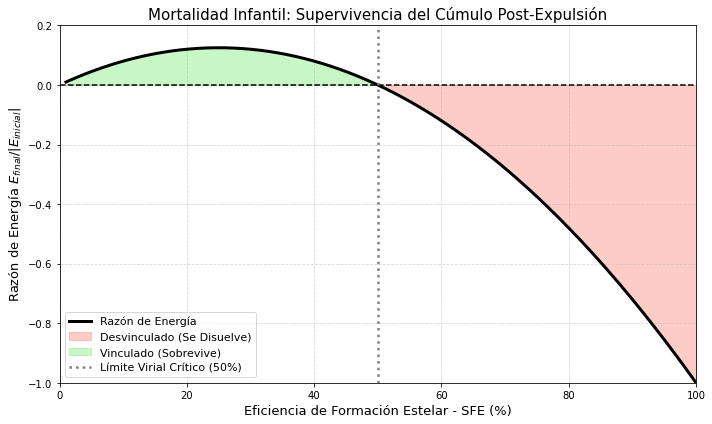

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de Eficiencia de Formación Estelar (SFE) de 1% a 100%
sfe = np.linspace(0.01, 1.0, 500)

# Ecuación teórica derivada: E_final / |E_inicial|
ratio_energy = sfe - 2.0 * sfe**2

plt.figure(figsize=(10, 6))

# Curva principal
plt.plot(sfe * 100, ratio_energy, 'k-', lw=3, label='Razón de Energía')

# Sombrear las regiones físicas
plt.fill_between(sfe * 100, ratio_energy, 0, where=(ratio_energy < 0),
                 color='salmon', alpha=0.4, label='Desvinculado (Se Disuelve)')
plt.fill_between(sfe * 100, ratio_energy, 0, where=(ratio_energy >= 0),
                 color='lightgreen', alpha=0.5, label='Vinculado (Sobrevive)')

# Líneas de referencia
plt.axhline(0, color='black', linestyle='--')
plt.axvline(50, color='gray', linestyle=':', lw=2.5, label='Límite Virial Crítico (50%)')

# Detalles estéticos
plt.xlabel('Eficiencia de Formación Estelar - SFE (%)', fontsize=13)
plt.ylabel(r'Razón de Energía $E_{final} / |E_{inicial}|$', fontsize=13)
plt.title('Mortalidad Infantil: Supervivencia del Cúmulo Post-Expulsión', fontsize=15)
plt.xlim(0, 100)
plt.ylim(-1.0, 0.2)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Lecturas Recomendadas (Estado del Arte)
Los siguientes artículos representan la vanguardia investigativa. Se recomienda su lectura y discusión en seminario.

1.  **Offner, S. S. R., et al. (2022).** *"The Origin of Star Clusters and the Initial Mass Function"*. Protostars and Planets VII.

    *Relevancia*: Revisión masiva y reciente sobre cómo el colapso turbulento da origen a la IMF).

2.  **Grudić, M. Y., et al. (2021).** *"STARFORGE: Toward a comprehensive numerical model of star cluster formation and feedback"*. MNRAS.

    *Relevancia*:Implementación de simulaciones MHD de vanguardia que modelan cúmulos enteros estrella por estrella).

3.  **Chevance, M., et al. (2022).** *"The life cycle of molecular clouds and star formation"*. Protostars and Planets VII.

    *Relevancia*: Observacional: mapeo detallado del rápido ciclo de vida de las nubes y el tiempo de dispersión por feedback.

4.  **Krumholz, M. R., et al. (2019).** *"Star Clusters Across Cosmic Time"*. Annual Review of Astronomy and Astrophysics, 57, 227-303.

    *Relevancia*: Sintetiza la cinemática de los cúmulos desde su nacimiento hasta su disolución.

5.  **Kennicutt, R. C., & Evans, N. J. (2012).** *"Star Formation in the Milky Way and Nearby Galaxies"*. Annual Review of Astronomy and Astrophysics.

    *Relevancia*: La biblia moderna sobre cómo se mide empíricamente el SFE y SFR.

6. **Salpeter, E. E. (1955).** *"The Luminosity Function and Stellar Evolution"*. The Astrophysical Journal, 121, 161.

    *Relevancia*:: El fundamento histórico. Primera vez que se derivó una función de distribución a partir de la luminosidad empírica, estableciendo el índice de −2.35 que aún sostiene el límite superior de masa hoy en día.

7. **Kroupa, P. (2001)**. *"On the variation of the initial mass function"*. Monthly Notices of the Royal Astronomical Society, 322(2), 231-246.

    *Relevancia*: Define el modelo de ley de potencias fragmentada (broken power-law) que los estudiantes utilizarán por defecto en casi todas sus investigaciones futuras. Fundamental para comprender las incertezas en el recuento de enanas rojas.

8. **Chabrier, G. (2003)**. *"Galactic Stellar and Substellar Initial Mass Function"*. Publications of the Astronomical Society of the Pacific, 115(809), 763-795.

    *Relevancia*: Referencia definitiva para la función log-normal. Vital porque ancla el "turn-over" de la IMF a procesos físicos derivados de la termodinámica del gas y no solo a ajustes puramente matemáticos empíricos.

9. **Bastian, N., Covey, K. R., & Meyer, M. R. (2010)**. *"A Universal Stellar Initial Mass Function? A Critical Look at Variations"*. Annual Review of Astronomy and Astrophysics, 48, 339-389.

    *Relevancia*: Es una revisión de alto impacto sobre un debate abierto. Examina rigurosamente las observaciones de ambientes extremos (starbursts, centros galácticos) para retar el dogma de la "IMF Universal". Enséñales a los estudiantes que la astrofísica no está escrita en piedra.

10. **Lada, C. J., & Lada, E. A. (2003)**. *"Embedded Clusters in Molecular Clouds"*. Annual Review of Astronomy and Astrophysics, 41, 57-115.

    *Relevancia*: Este review consolidó el concepto de "Infant Mortality". Es la lectura obligatoria para entender cómo el feedback estelar (Strömgren) controla estadísticamente el destino de la Vía Láctea, evitando que todo su gas colapse en un tiempo de caída libre.

## 6. Ejercicios Propuestos para los Estudiantes

**Ejercicio 1:** Asuma una IMF de Salpeter $\xi(m) = \xi_0 m^{-2.35}$. Para un cúmulo estelar recién formado cuyas estrellas están limitadas entre $0.1 M_\odot$ y $120 M_\odot$:
* a) Derive analíticamente la fracción del número total de estrellas que tienen una masa $> 8 M_\odot$.
* b) Derive analíticamente la fracción de la masa total contenida en dichas estrellas. Discuta la discrepancia.

**Ejercicio 2:** Una estrella tipo O5 de la secuencia principal emite $Q_H = 3 \times 10^{49}$ fotones ionizantes por segundo en un núcleo con densidad $n = 10^4 \text{ cm}^{-3}$ ($\alpha_B = 2.6 \times 10^{-13} \text{ cm}^3 \text{ s}^{-1}$). Calcule el radio de Strömgren $R_S$ en parsecs. Si la onda de choque expansiva limpia la nube a $10 \text{ km/s}$, ¿cuánto tardará en despejar un cúmulo de $2 \text{ pc}$ de radio?

**Ejercicio 3 (Python):** Escriba un script que utilice el método de Monte Carlo (aceptación-rechazo) para generar un cúmulo sintético de $10,000$ estrellas siguiendo la IMF multipartita de Kroupa (2001). Grafique el histograma resultante en escala log-log y calcule la masa promedio por estrella generada.

**Ejercicio 4 (Python):** Escriba un programa para integrar numéricamente las ecuaciones acopladas del colapso de Shu (Semana 2) utilizando la transformación geométrica $s = -\ln(x)$ y grafique la curva superpuesta a las asíntotas de caída libre de masa y velocidad.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

def plot_infant_mortality(sfe_percent):
    sfe_array = np.linspace(0.01, 1.0, 500)
    ratio_energy = sfe_array - 2.0 * sfe_array**2
    y_val = (sfe_percent/100) - 2.0 * (sfe_percent/100)**2

    plt.figure(figsize=(9, 6))
    plt.plot(sfe_array * 100, ratio_energy, 'k-', lw=2)
    plt.plot(sfe_percent, y_val, 'ro' if y_val < 0 else 'go', markersize=10)
    plt.axhline(0, ls='--', color='gray')
    plt.fill_between(sfe_array*100, ratio_energy, 0, where=(ratio_energy<0), color='red', alpha=0.1)
    plt.fill_between(sfe_array*100, ratio_energy, 0, where=(ratio_energy>=0), color='green', alpha=0.1)
    plt.title(f"Estado del cúmulo: {'Desvinculado' if y_val < 0 else 'Vinculado'}")
    plt.show()

interact(plot_infant_mortality, sfe_percent=widgets.IntSlider(min=1, max=100, step=1, value=10));

interactive(children=(IntSlider(value=10, description='sfe_percent', min=1), Output()), _dom_classes=('widget-…

In [4]:
from IPython.display import IFrame
IFrame(src="https://www.youtube.com/embed/M0Rj3hkkPf0", width="100%", height="500px")

In [5]:
## Escriba aquí su solución